# ProxDM From Scratch (MNIST, Low-Dim Image Setup)

**Beyond Scores: Proximal Diffusion Models** with low-level PyTorch blocks only.

First part for MNIST data and second part for low dimension data (dino data like in the paper and batman data)

My test data is at the very end of the notebook (batman graph point data)

The notebook is very long to comput (several hours on a rtx 5090)


In [1]:
import math
import copy
import random
import os
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# CUDA tuning for modern GPUs (RTX 5090 included)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
scaler = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)

print("device:", device)


device: cuda


## Experiment Config

We use the MNIST setup reported in the paper/repo:
- VP-SDE with linear noise schedule: `beta_min=0.1`, `beta_max=20`.
- U-Net backbone with attention at one resolution.
- Two-phase proximal training: first `L1`, then proximal matching with a decaying `zeta` (`gamma` in code). L1 norme can aproximate a problem of norme `l0`


In [ ]:
@dataclass
class TrainConfig:
    image_size: int = 32
    in_ch: int = 1

    beta_min: float = 0.1
    beta_max: float = 20.0

    ch: int = 64
    ch_mult: tuple = (1, 2, 2, 2)
    attn: tuple = (1,)
    num_res_blocks: int = 2
    dropout: float = 0.1
    use_checkpoint: bool = False

    batch_size: int = 512

    num_workers: int = 0 if os.name == "nt" else 8
    grad_clip: float = 1.0
    grad_accum_steps: int = 1 

    use_fused_adamw: bool = True

    score_lr: float = 2e-4
    score_warmup: int = 0

    prox_l1_iters: int = 75_000
    prox_total_iters: int = 225_000
    prox_pm_gamma_start: float = 1.0
    prox_pm_gamma_decay: float = 0.5
    prox_pm_gamma_stages: int = 2
    prox_l1_lr: float = 1e-4
    prox_pm_lr: float = 1e-5

    ema_decay: float = 0.9999

    sample_steps_candidates_prox: tuple = (5, 10, 20, 50, 100, 1000)


cfg = TrainConfig()
cfg


TrainConfig(image_size=32, in_ch=1, beta_min=0.1, beta_max=20.0, ch=64, ch_mult=(1, 2, 2, 2), attn=(1,), num_res_blocks=2, dropout=0.1, use_checkpoint=False, batch_size=512, num_workers=0, grad_clip=1.0, grad_accum_steps=1, use_fused_adamw=True, score_lr=0.0002, score_warmup=0, prox_l1_iters=75000, prox_total_iters=225000, prox_pm_gamma_start=1.0, prox_pm_gamma_decay=0.5, prox_pm_gamma_stages=2, prox_l1_lr=0.0001, prox_pm_lr=1e-05, ema_decay=0.9999, sample_steps_candidates_prox=(5, 10, 20, 50, 100, 1000))

## Data Pipeline (MNIST -> 32x32)

As in the official implementation, we pad MNIST from `28x28` to `32x32` and normalize to `[-1, 1]`.

This normalization is important because diffusion noise and denoising residuals are trained in a centered scale.


batch: (512, 1, 32, 32) range: (-1.0, 1.0)


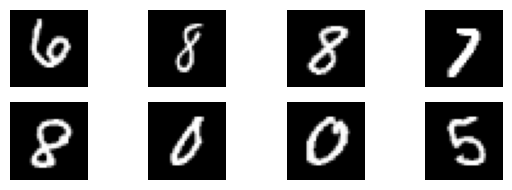

In [25]:
transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])

mnist_train = datasets.MNIST(
    root="data/mnist",
    train=True,
    download=True,
    transform=transform,
)
mnist_train = [img for img, _ in mnist_train]

loader_kwargs = {"pin_memory": device.type == "cuda"}
if cfg.num_workers > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

loader = DataLoader(
    mnist_train,
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=cfg.num_workers,
    **loader_kwargs,
)
train_loader = loader


def reset_train_iter():
    global train_iter
    train_iter = iter(train_loader)


def next_train_batch():
    global train_iter
    try:
        batch = next(train_iter)
        return batch[0] if isinstance(batch, (tuple, list)) else batch
    except StopIteration:
        train_iter = iter(train_loader)
        batch = next(train_iter)
        return batch[0] if isinstance(batch, (tuple, list)) else batch


reset_train_iter()

x0 = next_train_batch()
print("batch:", tuple(x0.shape), "range:", (x0.min().item(), x0.max().item()))

plt.figure(figsize=(6, 2))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = (x0[i, 0] + 1.0) * 0.5
    plt.imshow(img, cmap="gray")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Scalar Embeddings (Time and Lambda)

The paper conditions the network on `t` and `lambda`.

We use sinusoidal embeddings (same idea as transformer positional encodings), then a small MLP.
This keeps conditioning continuous and smooth across diffusion times and proximal strengths.


In [26]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


def sinusoidal_embedding(scalars: torch.Tensor, dim: int):
    assert dim % 2 == 0
    scalars = scalars * 1000.0
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000.0) * torch.arange(half, device=scalars.device, dtype=torch.float32) / (half - 1)
    )
    angles = scalars[:, None].float() * freqs[None, :]
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)


class ScalarEmbedding(nn.Module):
    def __init__(self, d_model: int, out_dim: int):
        super().__init__()
        self.d_model = d_model
        self.mlp = nn.Sequential(
            nn.Linear(d_model, out_dim),
            Swish(),
            nn.Linear(out_dim, out_dim),
        )
        self.initialize()

    def initialize(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, s: torch.Tensor):
        return self.mlp(sinusoidal_embedding(s, self.d_model))


## Core Building Blocks (ResNet + Attention)

The U-Net uses residual blocks and spatial self-attention.

The attention block is the transformer-style part: queries/keys/values on flattened spatial tokens.
This is the same design family used in DDPM-style U-Nets.


In [27]:
class DownSample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
        self.initialize()

    def initialize(self):
        nn.init.xavier_uniform_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)

    def forward(self, x, emb):
        return self.conv(x)


class UpSample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
        self.initialize()

    def initialize(self):
        nn.init.xavier_uniform_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)

    def forward(self, x, emb):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)


class AttnBlock(nn.Module):
    # Transformer-style self-attention over HxW tokens.
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(32, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
        self.initialize()

    def initialize(self):
        for layer in (self.q, self.k, self.v, self.proj):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
        # Small residual at init improves stability, matching official implementation.
        nn.init.xavier_uniform_(self.proj.weight, gain=1e-5)

    def forward(self, x):
        b, c, h, w = x.shape
        y = self.norm(x)

        q = self.q(y).permute(0, 2, 3, 1).reshape(b, h * w, c)
        k = self.k(y).reshape(b, c, h * w)
        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = F.softmax(attn, dim=-1)

        v = self.v(y).permute(0, 2, 3, 1).reshape(b, h * w, c)
        y = torch.bmm(attn, v).reshape(b, h, w, c).permute(0, 3, 1, 2)
        return x + self.proj(y)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim, dropout, attn=False, use_checkpoint=False):
        super().__init__()
        self.use_checkpoint = use_checkpoint
        self.block1 = nn.Sequential(
            nn.GroupNorm(32, in_ch),
            Swish(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
        )
        self.emb_proj = nn.Sequential(Swish(), nn.Linear(emb_dim, out_ch))
        self.block2 = nn.Sequential(
            nn.GroupNorm(32, out_ch),
            Swish(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
        )
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.attn = AttnBlock(out_ch) if attn else nn.Identity()
        self.initialize()

    def initialize(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        nn.init.xavier_uniform_(self.block2[-1].weight, gain=1e-5)

    def _forward(self, x, emb):
        h = self.block1(x)
        h = h + self.emb_proj(emb)[:, :, None, None]
        h = self.block2(h)
        h = h + self.shortcut(x)
        return self.attn(h)

    def forward(self, x, emb):
        if self.use_checkpoint:
            return torch.utils.checkpoint.checkpoint(self._forward, x, emb, use_reentrant=False)
        return self._forward(x, emb)


## U-Net Backbones

We define:
- `UNetTime` for score models (`x, t -> epsilon`).
- `UNetTimeLambda` for proximal models (`x, t, lambda -> epsilon`).

This mirrors the paper implementation detail: ProxDM has two conditioning branches (`t` and `lambda`).


In [ ]:
class UNet(nn.Module):
    def __init__(
        self,
        ch,
        ch_mult,
        attn,
        num_res_blocks,
        dropout,
        emb_dim,
        in_ch,
        use_checkpoint=False,
    ):
        super().__init__()
        assert all(i < len(ch_mult) for i in attn), "attn index out of bound"

        self.head = nn.Conv2d(in_ch, ch, 3, padding=1)

        self.downblocks = nn.ModuleList()
        chs = [ch]
        now_ch = ch
        for i, mult in enumerate(ch_mult):
            out_ch = ch * mult
            for _ in range(num_res_blocks):
                self.downblocks.append(
                    ResBlock(
                        now_ch,
                        out_ch,
                        emb_dim,
                        dropout,
                        attn=(i in attn),
                        use_checkpoint=use_checkpoint,
                    )
                )
                now_ch = out_ch
                chs.append(now_ch)
            if i != len(ch_mult) - 1:
                self.downblocks.append(DownSample(now_ch))
                chs.append(now_ch)

        self.middle = nn.ModuleList(
            [
                ResBlock(now_ch, now_ch, emb_dim, dropout, attn=True, use_checkpoint=use_checkpoint),
                ResBlock(now_ch, now_ch, emb_dim, dropout, attn=False, use_checkpoint=use_checkpoint),
            ]
        )

        self.upblocks = nn.ModuleList()
        for i, mult in reversed(list(enumerate(ch_mult))):
            out_ch = ch * mult
            for _ in range(num_res_blocks + 1):
                self.upblocks.append(
                    ResBlock(
                        chs.pop() + now_ch,
                        out_ch,
                        emb_dim,
                        dropout,
                        attn=(i in attn),
                        use_checkpoint=use_checkpoint,
                    )
                )
                now_ch = out_ch
            if i != 0:
                self.upblocks.append(UpSample(now_ch))

        self.tail = nn.Sequential(
            nn.GroupNorm(32, now_ch),
            Swish(),
            nn.Conv2d(now_ch, in_ch, 3, padding=1),
        )
        self.initialize()

    def initialize(self):
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        nn.init.xavier_uniform_(self.tail[-1].weight, gain=1e-5)
        nn.init.zeros_(self.tail[-1].bias)

    def forward(self, x, emb):
        h = self.head(x)
        hs = [h]

        for layer in self.downblocks:
            h = layer(h, emb)
            hs.append(h)

        for layer in self.middle:
            h = layer(h, emb)

        for layer in self.upblocks:
            if isinstance(layer, ResBlock):
                h = torch.cat([h, hs.pop()], dim=1)
            h = layer(h, emb)

        return self.tail(h)


class UNetTime(nn.Module):
    def __init__(self, ch, ch_mult, attn, num_res_blocks, dropout, in_ch, use_checkpoint=False):
        super().__init__()
        emb_dim = ch * 4
        self.time_emb = ScalarEmbedding(ch, emb_dim)
        self.unet = UNet(
            ch,
            ch_mult,
            attn,
            num_res_blocks,
            dropout,
            emb_dim,
            in_ch,
            use_checkpoint=use_checkpoint,
        )

    def forward(self, x, t):
        return self.unet(x, self.time_emb(t))


class UNetTimeLambda(nn.Module):
    def __init__(self, ch, ch_mult, attn, num_res_blocks, dropout, in_ch, use_checkpoint=False):
        super().__init__()
        emb_dim = ch * 4
        self.time_emb = ScalarEmbedding(ch, emb_dim // 2)
        self.lamb_emb = ScalarEmbedding(ch, emb_dim // 2)
        self.unet = UNet(
            ch,
            ch_mult,
            attn,
            num_res_blocks,
            dropout,
            emb_dim,
            in_ch,
            use_checkpoint=use_checkpoint,
        )

    def forward(self, x, t, lamb):
        emb = torch.cat([self.time_emb(t), self.lamb_emb(lamb)], dim=1)
        return self.unet(x, emb)


## VP-SDE and Model Wrappers

For VP diffusion: 

- `ScoreModel` converts epsilon prediction into score.
- `ProxModel` uses the paper reparameterization:
- `ProximalMatchingLoss` is the bounded loss used by proximal matching.


In [29]:
class SDE:
    def __init__(self, beta_min, beta_max):
        self.beta_min = beta_min
        self.beta_max = beta_max

    def beta(self, t):
        return self.beta_min + (self.beta_max - self.beta_min) * t

    def beta_integral(self, a, b):
        return (self.beta(a) + self.beta(b)) * (b - a) / 2


class ScoreModel(nn.Module):
    def __init__(self, eps_net, beta_min, beta_max):
        super().__init__()
        self.eps_net = eps_net
        self.sde = SDE(beta_min, beta_max)

    def compute_epsilon(self, x, t):
        return self.eps_net(x, t)

    def forward(self, x, t):
        alpha_t = torch.exp(-self.sde.beta_integral(0, t)).view(x.shape[0], 1, 1, 1)
        eps = self.eps_net(x, t)
        return -eps / torch.sqrt(1 - alpha_t)


class ProxModel(nn.Module):
    # Epsilon parameterization from ProxDM.
    def __init__(self, net, model_type="epsilon"):
        super().__init__()
        self.net = net
        self.model_type = model_type

    def forward(self, x, t, lamb):
        if self.model_type == "prox":
            return self.net(x, t, lamb)
        return x - self.net(x, t, lamb) * torch.sqrt(lamb).view(-1, 1, 1, 1)

    def compute_epsilon(self, x, t, lamb):
        if self.model_type == "epsilon":
            return self.net(x, t, lamb)
        return (x - self.net(x, t, lamb)) / torch.sqrt(lamb).view(-1, 1, 1, 1)


class ProximalMatchingLoss(nn.Module):
    # l_PM in the paper, with gamma equal to zeta.
    def forward(self, pred, target, gamma):
        b = pred.shape[0]
        mse = (pred - target).pow(2).reshape(b, -1).mean(1)
        return 1.0 - torch.exp(-(mse / (gamma**2)))


## Training Objectives (Score vs Proximal Matching)

Score training uses standard denoising MSE on $\varepsilon$

Prox training follows the proximal matching extension from the paper:
- Sample $(t,\lambda)$ build $x_t$, then noisy input $y = x_t + \sqrt{\lambda}\,\varepsilon$.
- Predict either prox directly or residual epsilon.
- Start with `L1`, then switch to proximal matching loss with decaying `zeta` (`gamma`).

This corresponds to Eq. (7)-(9) and Algorithm 2 in the paper.


In [ ]:
def sample_t_score(batch_size, device):
    return torch.rand(batch_size, device=device)


def sample_t_lamb(
    batch_size,
    sde,
    device,
    candidates,
    weights_type="log",
    discretization="hybrid",
    n_steps_candidates=None,
    weights=None,
):
    if n_steps_candidates is None:
        n_steps_candidates = torch.tensor(candidates, device=device)

    if weights is None:
        if weights_type == "log":
            weights = torch.log10(n_steps_candidates.float())
        else:
            weights = torch.ones_like(n_steps_candidates, dtype=torch.float32)

    idx = torch.multinomial(weights, batch_size, replacement=True)
    n_steps = n_steps_candidates[idx]
    delta_t = 1.0 / n_steps

    t = torch.rand(batch_size, device=device)
    t = torch.floor(t / delta_t) * delta_t
    t = torch.clamp(t, max=1 - delta_t)
    t_plus = t + delta_t

    eff = sde.beta_integral(t, t_plus)
    if discretization == "hybrid":
        lamb = eff
    else:
        lamb = eff / (1 - 0.5 * eff)

    return t, lamb, {"step_num": n_steps}


class ScoreTrainerVP(nn.Module):
    def __init__(self, model, beta_min, beta_max):
        super().__init__()
        self.model = model
        self.sde = SDE(beta_min, beta_max)

    def forward(self, x0):
        t = sample_t_score(x0.shape[0], x0.device)
        alpha_t = torch.exp(-self.sde.beta_integral(0, t)).view(x0.shape[0], 1, 1, 1)

        noise = torch.randn_like(x0)
        x_t = torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * noise
        pred = self.model.compute_epsilon(x_t, t)
        return F.mse_loss(pred, noise, reduction="none").mean(dim=(1, 2, 3))


class ProxTrainerVP(nn.Module):
    def __init__(self, model, beta_min, beta_max, loss_on="epsilon"):
        super().__init__()
        self.model = model
        self.sde = SDE(beta_min, beta_max)
        self.loss_on = loss_on
        self.pm_loss = ProximalMatchingLoss()

    def forward(self, x0, loss_params, candidates, discretization="hybrid"):
        # Avoid stateful tensor caching here; it can break torch.compile + CUDA graphs.
        n_steps_candidates = torch.tensor(candidates, device=x0.device)
        weights = torch.log10(n_steps_candidates.float())
        t, lamb, _ = sample_t_lamb(
            x0.shape[0],
            self.sde,
            x0.device,
            candidates=candidates,
            discretization=discretization,
            n_steps_candidates=n_steps_candidates,
            weights=weights,
        )

        alpha_t = torch.exp(-self.sde.beta_integral(0, t)).view(x0.shape[0], 1, 1, 1)
        eps_t = torch.randn_like(x0)
        x_t = torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * eps_t

        eps_pm = torch.randn_like(x0)
        y = x_t + torch.sqrt(lamb).view(-1, 1, 1, 1) * eps_pm

        if self.loss_on == "prox":
            pred = self.model(y, t, lamb)
            target = x_t
        else:
            pred = self.model.compute_epsilon(y, t, lamb)
            target = eps_pm

        if loss_params["type"] == "l1":
            return F.l1_loss(pred, target, reduction="none").mean(dim=(1, 2, 3))
        if loss_params["type"] == "prox_match":
            return self.pm_loss(pred, target, loss_params["gamma"])
        return F.mse_loss(pred, target, reduction="none").mean(dim=(1, 2, 3))


## Sampling Algorithms

We implement the same VP discretizations as in ProxDM:
- Score sampler: Euler-Maruyama with optional final denoising step (`eps` variant).
- Prox sampler: `hybrid` and `backward` updates from Algorithm 1.

The core idea from class: discretization choice changes stability/step-efficiency even with similar per-step model cost.


In [31]:
@torch.no_grad()
def score_sample_euler_maruyama_eps(model, sde, n_samples, n_steps, data_dim, time_eps=1e-3):
    x = torch.randn(n_samples, *data_dim, device=device)
    times = torch.linspace(1.0, time_eps, n_steps, device=device)

    for i in range(n_steps):
        t_now = times[i]
        if i == n_steps - 1:
            dt = time_eps
        else:
            dt = (1.0 - time_eps) / (n_steps - 1)

        eff = sde.beta(t_now) * dt
        vec_t = torch.full((x.shape[0],), t_now, device=x.device)
        score = model(x, vec_t)

        noise = 0.0 if i == n_steps - 1 else torch.randn_like(x)
        x = (1 + 0.5 * eff) * x + eff * score + torch.sqrt(eff) * noise

    return x


@torch.no_grad()
def prox_sample_hybrid(model, sde, n_samples, n_steps, data_dim, time_eps=0.0):
    x = torch.randn(n_samples, *data_dim, device=device)
    times = torch.linspace(time_eps, 1.0, n_steps + 1, device=device)

    for i in range(n_steps - 1, -1, -1):
        t_now, t_new = times[i + 1], times[i]
        eff = sde.beta_integral(t_new, t_now)
        lamb = eff

        y = (1 + 0.5 * eff) * x + torch.sqrt(eff) * torch.randn_like(x)
        vec_t = torch.full((x.shape[0],), t_new, device=x.device)
        vec_l = torch.full((x.shape[0],), lamb, device=x.device)
        x = model(y, vec_t, vec_l)

    return x


@torch.no_grad()
def prox_sample_backward(model, sde, n_samples, n_steps, data_dim, time_eps=0.0):
    x = torch.randn(n_samples, *data_dim, device=device)
    times = torch.linspace(time_eps, 1.0, n_steps + 1, device=device)

    for i in range(n_steps - 1, -1, -1):
        t_now, t_new = times[i + 1], times[i]
        eff = sde.beta_integral(t_new, t_now)
        lamb = eff / (1 - 0.5 * eff)

        y = (x + torch.sqrt(eff) * torch.randn_like(x)) / (1 - 0.5 * eff)
        vec_t = torch.full((x.shape[0],), t_new, device=x.device)
        vec_l = torch.full((x.shape[0],), lamb, device=x.device)
        x = model(y, vec_t, vec_l)

    return x


## Optimization Utilities (EMA + Schedules)

We keep the optimizer simple (`AdamW`) and follow the ProxDM two-stage schedule:
1. `L1` warm-start for the proximal network.
2. Proximal matching with decaying `gamma` (`zeta`).

EMA is used for stable sampling checkpoints.


In [32]:
def set_lr(optimizer, lr):
    for g in optimizer.param_groups:
        g["lr"] = lr


def ema_update(model, ema_model, decay=0.9999):
    with torch.no_grad():
        for ema_p, p in zip(ema_model.parameters(), model.parameters()):
            ema_p.mul_(decay).add_(p, alpha=1 - decay)

        # Buffers (for example running stats) are copied directly.
        for ema_b, b in zip(ema_model.buffers(), model.buffers()):
            ema_b.copy_(b)


class PMLossSchedule:
    def __init__(self, total_iters, l1_iters, gamma_start, gamma_decay, gamma_stages, l1_lr, pm_lr):
        self.total_iters = total_iters
        self.l1_iters = l1_iters
        self.pm_iters = total_iters - l1_iters
        self.decay_every = max(1, self.pm_iters // gamma_stages)

        self.gamma_start = gamma_start
        self.gamma_decay = gamma_decay
        self.gamma_stages = gamma_stages

        self.l1_lr = l1_lr
        self.pm_lr = pm_lr

    def get(self, it):
        if it <= self.l1_iters:
            return {"type": "l1"}, self.l1_lr

        it_pm = it - self.l1_iters - 1
        decay_id = min(it_pm // self.decay_every, self.gamma_stages - 1)
        gamma = self.gamma_start * (self.gamma_decay ** decay_id)
        return {"type": "prox_match", "gamma": gamma}, self.pm_lr


## Build Models

We create both families:
- Score model (`UNetTime` + `ScoreModel`).
- Prox model (`UNetTimeLambda` + `ProxModel`, epsilon parameterization).

All tensors are moved to CUDA and converted to channels-last for faster convolutions.


In [ ]:
score_net = UNetTime(
    ch=cfg.ch,
    ch_mult=cfg.ch_mult,
    attn=cfg.attn,
    num_res_blocks=cfg.num_res_blocks,
    dropout=cfg.dropout,
    in_ch=cfg.in_ch,
    use_checkpoint=cfg.use_checkpoint,
).to(device).to(memory_format=torch.channels_last)

prox_net = UNetTimeLambda(
    ch=cfg.ch,
    ch_mult=cfg.ch_mult,
    attn=cfg.attn,
    num_res_blocks=cfg.num_res_blocks,
    dropout=cfg.dropout,
    in_ch=cfg.in_ch,
    use_checkpoint=cfg.use_checkpoint,
).to(device).to(memory_format=torch.channels_last)

score_model = ScoreModel(score_net, cfg.beta_min, cfg.beta_max).to(device)
prox_model = ProxModel(prox_net, model_type="epsilon").to(device)

score_trainer = ScoreTrainerVP(score_model, cfg.beta_min, cfg.beta_max).to(device)
prox_trainer = ProxTrainerVP(prox_model, cfg.beta_min, cfg.beta_max, loss_on="epsilon").to(device)

use_torch_compile = False  # safer default in notebook sessions
if use_torch_compile and device.type == "cuda" and hasattr(torch, "compile"):
    try:
        compile_mode = "max-autotune-no-cudagraphs"
        score_trainer = torch.compile(score_trainer, mode=compile_mode)
    except Exception as e:
        print("torch.compile fallback:", e)

def make_adamw(params, lr):
    kwargs = {"lr": lr}
    if device.type == "cuda" and cfg.use_fused_adamw:
        kwargs["fused"] = True

    try:
        return torch.optim.AdamW(params, **kwargs)
    except TypeError:
        kwargs.pop("fused", None)
        return torch.optim.AdamW(params, **kwargs)


score_opt = make_adamw(score_model.parameters(), cfg.score_lr)
prox_opt = make_adamw(prox_model.parameters(), cfg.prox_l1_lr)

score_ema = copy.deepcopy(score_model).eval()
prox_ema = copy.deepcopy(prox_model).eval()

sde = SDE(cfg.beta_min, cfg.beta_max)

print("score params:", sum(p.numel() for p in score_model.parameters() if p.requires_grad))
print("prox params:", sum(p.numel() for p in prox_model.parameters() if p.requires_grad))
print("gradient checkpointing:", cfg.use_checkpoint)
print("micro-batch:", cfg.batch_size, "grad_accum:", cfg.grad_accum_steps, "effective batch:", cfg.batch_size * cfg.grad_accum_steps)


score params: 8949761
prox params: 8916993
gradient checkpointing: False
micro-batch: 512 grad_accum: 1 effective batch: 512


## Training Loops

Below are minimal loops for:
- **Score model** (standard epsilon MSE).
- **Prox model** (L1 pretrain + proximal matching).

In [34]:
def one_step_score():
    score_model.train()
    score_opt.zero_grad(set_to_none=True)

    running_loss = torch.zeros((), device=device)
    accum = max(1, int(cfg.grad_accum_steps))

    for _ in range(accum):
        if hasattr(torch, "compiler") and hasattr(torch.compiler, "cudagraph_mark_step_begin"):
            torch.compiler.cudagraph_mark_step_begin()
        x = next_train_batch().to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda" if device.type == "cuda" else "cpu",
            dtype=amp_dtype,
            enabled=(device.type == "cuda"),
        ):
            loss = score_trainer(x).mean()

        running_loss = running_loss + loss.detach()
        scaler.scale(loss / accum).backward()

    if cfg.grad_clip is not None:
        scaler.unscale_(score_opt)
        torch.nn.utils.clip_grad_norm_(score_model.parameters(), cfg.grad_clip)

    scaler.step(score_opt)
    scaler.update()

    ema_update(score_model, score_ema, cfg.ema_decay)
    return (running_loss / accum).item()


def one_step_prox(loss_params, lr, discretization="hybrid"):
    prox_model.train()
    set_lr(prox_opt, lr)
    prox_opt.zero_grad(set_to_none=True)

    running_loss = torch.zeros((), device=device)
    accum = max(1, int(cfg.grad_accum_steps))

    for _ in range(accum):
        if hasattr(torch, "compiler") and hasattr(torch.compiler, "cudagraph_mark_step_begin"):
            torch.compiler.cudagraph_mark_step_begin()
        x = next_train_batch().to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda" if device.type == "cuda" else "cpu",
            dtype=amp_dtype,
            enabled=(device.type == "cuda"),
        ):
            loss = prox_trainer(
                x,
                loss_params=loss_params,
                candidates=cfg.sample_steps_candidates_prox,
                discretization=discretization,
            ).mean()

        running_loss = running_loss + loss.detach()
        scaler.scale(loss / accum).backward()

    if cfg.grad_clip is not None:
        scaler.unscale_(prox_opt)
        torch.nn.utils.clip_grad_norm_(prox_model.parameters(), cfg.grad_clip)

    scaler.step(prox_opt)
    scaler.update()

    ema_update(prox_model, prox_ema, cfg.ema_decay)
    return (running_loss / accum).item()


## Quick Training (Short)

Run this cell first to verify everything works on your machine.
I use it to make sure everything work before long run

[score] it=0010 loss=0.8925
[score] it=0020 loss=0.6042
[score] it=0030 loss=0.3572
[prox] it=0050 loss=0.7059 mode={'type': 'l1'}
[prox] it=0100 loss=0.6799 mode={'type': 'l1'}
[prox] it=0150 loss=0.5085 mode={'type': 'prox_match', 'gamma': 1.0}
[prox] it=0200 loss=0.9115 mode={'type': 'prox_match', 'gamma': 0.5}


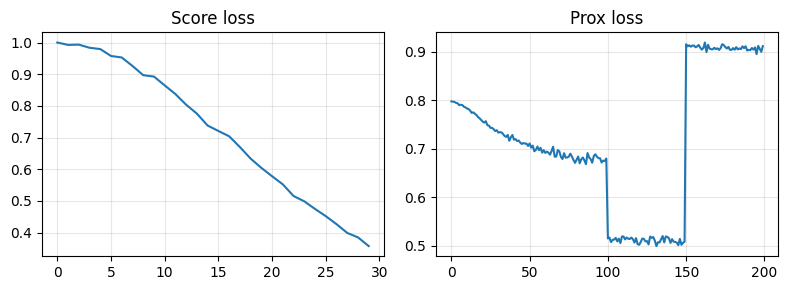

In [35]:
# quick score warmup
score_losses = []
for it in range(1, 31):
    loss = one_step_score()
    score_losses.append(loss)
    if it % 10 == 0:
        print(f"[score] it={it:04d} loss={loss:.4f}")

# quick prox warmup + pm
prox_sched = PMLossSchedule(
    total_iters=200,
    l1_iters=100,
    gamma_start=cfg.prox_pm_gamma_start,
    gamma_decay=cfg.prox_pm_gamma_decay,
    gamma_stages=cfg.prox_pm_gamma_stages,
    l1_lr=cfg.prox_l1_lr,
    pm_lr=cfg.prox_pm_lr,
)

prox_losses = []
for it in range(1, 201):
    loss_params, lr = prox_sched.get(it)
    loss = one_step_prox(loss_params, lr, discretization="hybrid")
    prox_losses.append(loss)
    if it % 50 == 0:
        print(f"[prox] it={it:04d} loss={loss:.4f} mode={loss_params}")

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(score_losses)
plt.title("Score loss")
plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(prox_losses)
plt.title("Prox loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Sampling and Visual Comparison

We now compare generated samples from:
- score sampler (SDE Euler-Maruyama with final denoising step),
- ProxDM hybrid,

Even in short training, this gives a qualitative sanity check.


In [36]:
def show_grid(x, n=32, title=""):
    x = x[:n].detach().float().cpu()
    x = ((x + 1) * 0.5).clamp(0, 1)
    cols = 8
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols, rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(x[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

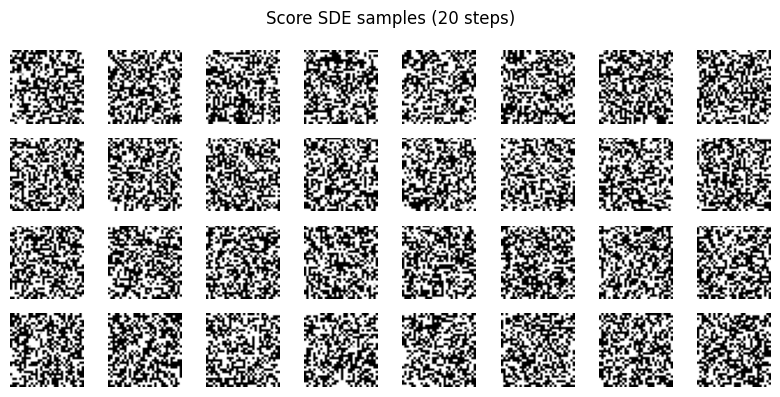

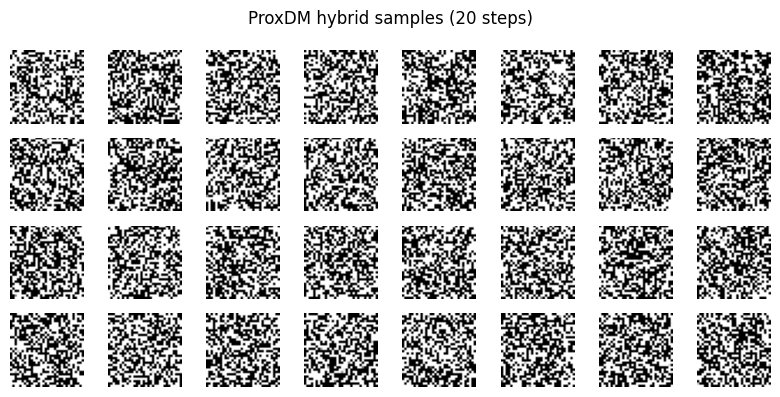

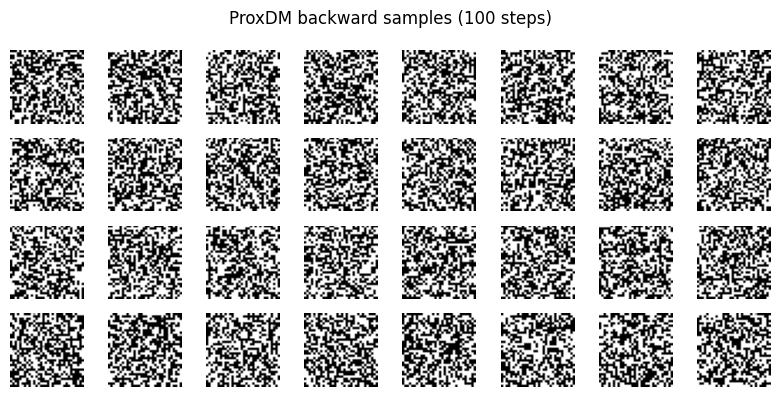

In [ ]:



steps = 20
with torch.no_grad():
    score_ema.eval()
    prox_ema.eval()

    score_samples = score_sample_euler_maruyama_eps(
        model=score_ema,
        sde=sde,
        n_samples=64,
        n_steps=steps,
        data_dim=(1, cfg.image_size, cfg.image_size),
        time_eps=1e-3,
    )

    prox_h_samples = prox_sample_hybrid(
        model=prox_ema,
        sde=sde,
        n_samples=64,
        n_steps=steps,
        data_dim=(1, cfg.image_size, cfg.image_size),
        time_eps=0.0,
    )

    prox_b_samples = prox_sample_backward(
        model=prox_ema,
        sde=sde,
        n_samples=64,
        n_steps=100,
        data_dim=(1, cfg.image_size, cfg.image_size),
        time_eps=0.0,
    )

show_grid(score_samples, title=f"Score SDE samples ({steps} steps)")
show_grid(prox_h_samples, title=f"ProxDM hybrid samples ({steps} steps)")
show_grid(prox_b_samples, title="ProxDM backward samples (100 steps)")


## Full Training Routines (Paper-Like)

The following functions are for real training runs.

They keep the same logic as the official implementation, but in one notebook and with simple code:
- score training,
- prox training with `L1 -> PM` schedule,
- checkpoint save/load.


In [ ]:
def save_ckpt(path, model, ema_model, optimizer, it):
    torch.save(
        {
            "it": it,
            "model": model.state_dict(),
            "ema": ema_model.state_dict(),
            "opt": optimizer.state_dict(),
        },
        path,
    )


def _scaled_l1_iters(total_iters, full_total_iters, full_l1_iters):
    if total_iters == full_total_iters:
        return full_l1_iters

    l1_ratio = full_l1_iters / full_total_iters
    l1_iters = int(round(total_iters * l1_ratio))
    return max(1, min(total_iters - 1, l1_iters))


def train_score(total_iters=20_000, save_every=5_000, out_dir="output/score"):
    import os

    os.makedirs(out_dir, exist_ok=True)
    reset_train_iter()

    losses = []
    for it in range(1, total_iters + 1):
        if cfg.score_warmup > 0:
            lr = cfg.score_lr * min(it, cfg.score_warmup) / cfg.score_warmup
            set_lr(score_opt, lr)

        loss = one_step_score()
        losses.append(loss)

        if it % 100 == 0:
            print(f"[score] it={it}/{total_iters} loss={loss:.4f}")

        if it % save_every == 0 or it == total_iters:
            save_ckpt(f"{out_dir}/ckpt_{it}.pt", score_model, score_ema, score_opt, it)

    return losses


def train_prox(
    total_iters=225_000,
    save_every=25_000,
    out_dir="output/prox",
    discretization="hybrid",
    l1_iters=None,
):
    import os

    os.makedirs(out_dir, exist_ok=True)
    reset_train_iter()

    if l1_iters is None:
        # Official repo ratio on MNIST is 75k / 225k = 1/3.
        l1_iters = _scaled_l1_iters(total_iters, cfg.prox_total_iters, cfg.prox_l1_iters)
    l1_iters = max(1, min(total_iters - 1, int(l1_iters)))

    print(
        f"[prox-schedule] total={total_iters:,}  "
        f"l1={l1_iters:,}  pm={total_iters - l1_iters:,}"
    )

    sched = PMLossSchedule(
        total_iters=total_iters,
        l1_iters=l1_iters,
        gamma_start=cfg.prox_pm_gamma_start,
        gamma_decay=cfg.prox_pm_gamma_decay,
        gamma_stages=cfg.prox_pm_gamma_stages,
        l1_lr=cfg.prox_l1_lr,
        pm_lr=cfg.prox_pm_lr,
    )

    losses = []
    for it in range(1, total_iters + 1):
        loss_params, lr = sched.get(it)
        loss = one_step_prox(loss_params, lr, discretization=discretization)
        losses.append(loss)

        if it % 100 == 0:
            print(f"[prox-{discretization}] it={it}/{total_iters} loss={loss:.4f} params={loss_params}")

        if it % save_every == 0 or it == total_iters:
            save_ckpt(f"{out_dir}/ckpt_{it}.pt", prox_model, prox_ema, prox_opt, it)

    return losses, l1_iters


In [ ]:
import os, time

long_history_iters = []
long_history_score_loss = []
long_history_prox_loss = []

#  1. Score model
print("=" * 60)
print("PHASE 1 – Score model training")
print("=" * 60)

# Free prox training tensors during score phase (helps single-GPU VRAM).
if device.type == "cuda":
    prox_model.to("cpu")
    prox_trainer.to("cpu")
    prox_ema.to("cpu")
    score_model.to(device)
    score_trainer.to(device)
    score_ema.to(device)
    torch.cuda.empty_cache()

t0 = time.time()
score_losses_long = train_score(
    total_iters=20_000,
    save_every=5_000,
    out_dir="output/score",
)
elapsed = time.time() - t0
print(f"\nScore training done in {elapsed/60:.1f} min")




PHASE 1 – Score model training
[score] it=100/20000 loss=0.0338
[score] it=200/20000 loss=0.0300
[score] it=300/20000 loss=0.0237
[score] it=400/20000 loss=0.0236
[score] it=500/20000 loss=0.0249
[score] it=600/20000 loss=0.0222
[score] it=700/20000 loss=0.0216
[score] it=800/20000 loss=0.0210
[score] it=900/20000 loss=0.0201
[score] it=1000/20000 loss=0.0237
[score] it=1100/20000 loss=0.0187
[score] it=1200/20000 loss=0.0199
[score] it=1300/20000 loss=0.0188
[score] it=1400/20000 loss=0.0187
[score] it=1500/20000 loss=0.0200
[score] it=1600/20000 loss=0.0191
[score] it=1700/20000 loss=0.0189
[score] it=1800/20000 loss=0.0184
[score] it=1900/20000 loss=0.0208
[score] it=2000/20000 loss=0.0208
[score] it=2100/20000 loss=0.0190
[score] it=2200/20000 loss=0.0187
[score] it=2300/20000 loss=0.0185
[score] it=2400/20000 loss=0.0170
[score] it=2500/20000 loss=0.0174
[score] it=2600/20000 loss=0.0187
[score] it=2700/20000 loss=0.0161
[score] it=2800/20000 loss=0.0182
[score] it=2900/20000 loss

In [40]:
# 2. Prox model – hybrid 
print("\n" + "=" * 60)
print("PHASE 2 Prox model training (hybrid discretization)")
print("  NOTE: for short runs we preserve the official 1/3 L1 ratio.")
print("=" * 60)

prox_total_iters_long = 20_000  # local budget run (paper config is 225_000, not everybody has 4 h100!!!!)

# Free score training tensors before prox phase (helps single-GPU VRAM).
if device.type == "cuda":
    score_model.to("cpu")
    score_trainer.to("cpu")
    score_ema.to("cpu")
    prox_model.to(device)
    prox_trainer.to(device)
    prox_ema.to(device)
    torch.cuda.empty_cache()

t0 = time.time()
prox_losses_long, prox_l1_iters_long = train_prox(
    total_iters=prox_total_iters_long,
    save_every=5_000,
    out_dir="output/prox_hybrid",
    discretization="hybrid",
    l1_iters=None,  # auto-scale from official ratio (75k/225k)
)
elapsed = time.time() - t0
print(f"\nProx training done in {elapsed/60:.1f} min")
print(f"Effective L1 warm-up used: {prox_l1_iters_long:,} / {prox_total_iters_long:,}")




PHASE 2 – Prox model training (hybrid discretization)
  NOTE: for short runs we preserve the official 1/3 L1 ratio.
[prox-schedule] total=20,000  l1=6,667  pm=13,333
[prox-hybrid] it=100/20000 loss=0.6579 params={'type': 'l1'}
[prox-hybrid] it=200/20000 loss=0.6711 params={'type': 'l1'}
[prox-hybrid] it=300/20000 loss=0.6684 params={'type': 'l1'}
[prox-hybrid] it=400/20000 loss=0.6802 params={'type': 'l1'}
[prox-hybrid] it=500/20000 loss=0.6625 params={'type': 'l1'}
[prox-hybrid] it=600/20000 loss=0.6689 params={'type': 'l1'}
[prox-hybrid] it=700/20000 loss=0.6478 params={'type': 'l1'}
[prox-hybrid] it=800/20000 loss=0.6578 params={'type': 'l1'}
[prox-hybrid] it=900/20000 loss=0.6650 params={'type': 'l1'}
[prox-hybrid] it=1000/20000 loss=0.6605 params={'type': 'l1'}
[prox-hybrid] it=1100/20000 loss=0.6549 params={'type': 'l1'}
[prox-hybrid] it=1200/20000 loss=0.6704 params={'type': 'l1'}
[prox-hybrid] it=1300/20000 loss=0.6610 params={'type': 'l1'}
[prox-hybrid] it=1400/20000 loss=0.6

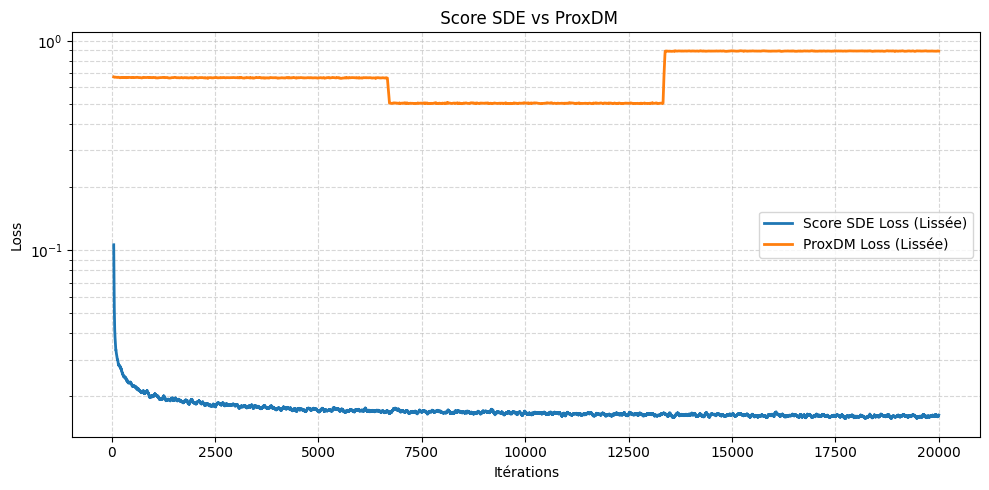

In [41]:


def plot_training_losses(score_losses, prox_losses, window_size=50):
    def smooth(y, box_pts):

        box_pts = min(box_pts, len(y)) 
        box = np.ones(box_pts) / box_pts
        y_smooth = np.convolve(y, box, mode='valid')
        return y_smooth, box_pts

    plt.figure(figsize=(10, 5))
    
    iters_score = np.arange(1, len(score_losses) + 1)
    iters_prox = np.arange(1, len(prox_losses) + 1)
    
    score_smooth, w_score = smooth(score_losses, window_size)
    prox_smooth, w_prox = smooth(prox_losses, window_size)
    
    plt.plot(iters_score[w_score-1:], score_smooth, label='Score SDE Loss (Lissée)', color='#1f77b4', linewidth=2)
    plt.plot(iters_prox[w_prox-1:], prox_smooth, label='ProxDM Loss (Lissée)', color='#ff7f0e', linewidth=2)
    
    plt.yscale('log') 
    plt.xlabel('Itérations')
    plt.ylabel('Loss')
    plt.title(' Score SDE vs ProxDM')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()
plot_training_losses(score_losses_long, prox_losses_long)

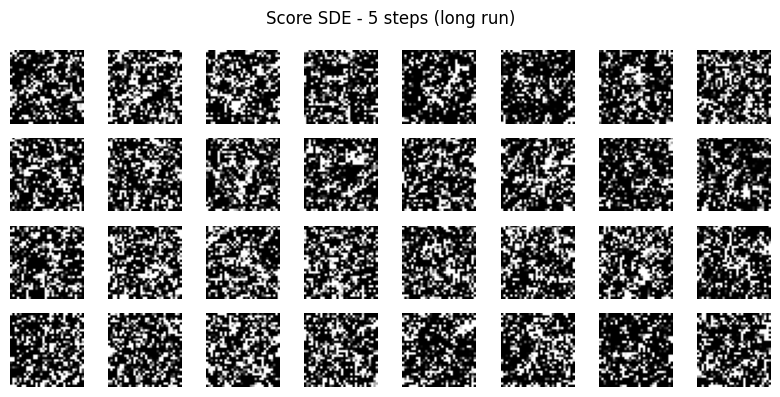

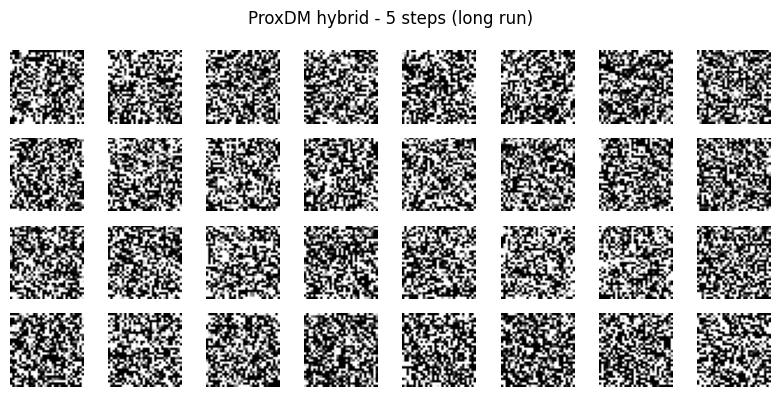

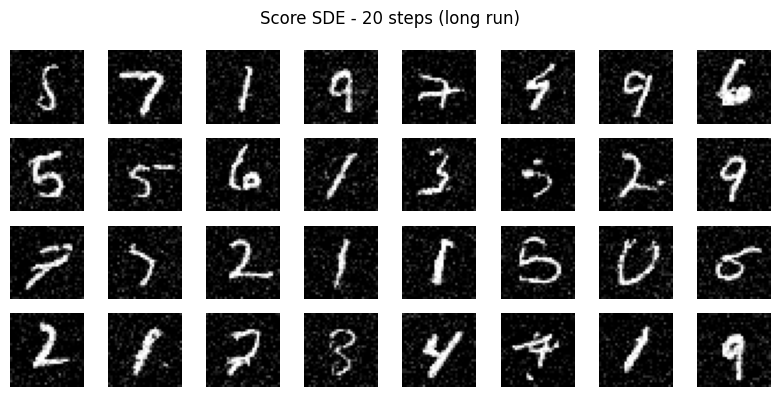

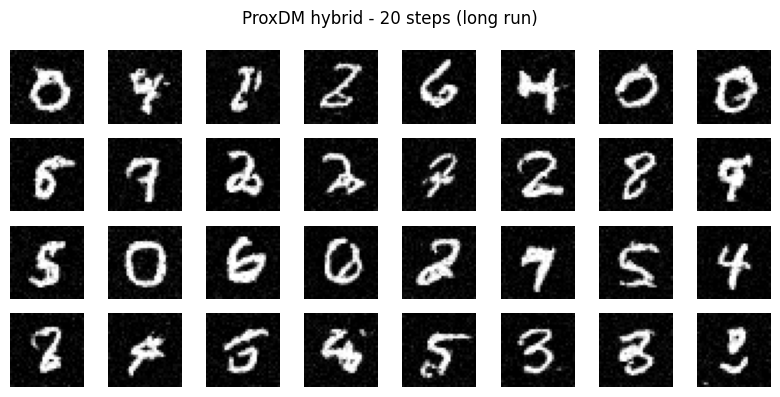

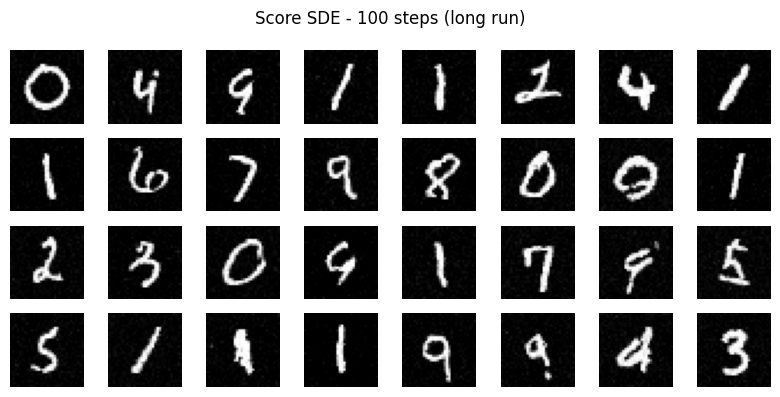

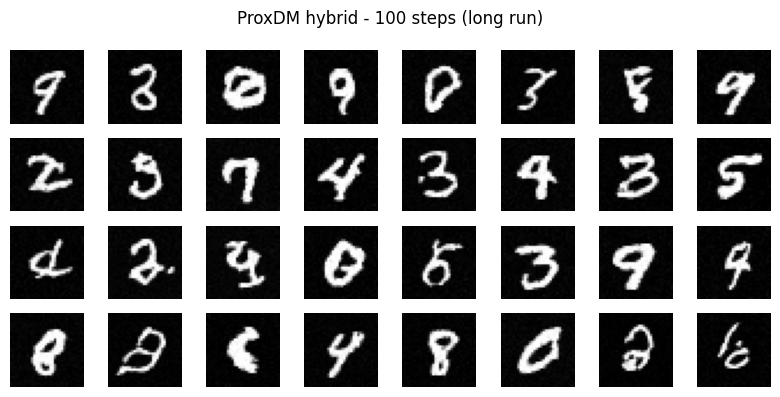

In [42]:

# 4. Final visual samples 
if device.type == "cuda":
    score_ema.to(device)
    prox_ema.to(device)

score_ema.eval()
prox_ema.eval()

for n_steps in (5, 20, 100):
    with torch.no_grad():
        sc = score_sample_euler_maruyama_eps(
            score_ema,
            sde,
            n_samples=64,
            n_steps=n_steps,
            data_dim=(1, cfg.image_size, cfg.image_size),
            time_eps=1e-3,
        )
        ph = prox_sample_hybrid(
            prox_ema,
            sde,
            n_samples=64,
            n_steps=n_steps,
            data_dim=(1, cfg.image_size, cfg.image_size),
            time_eps=0.0,
        )
    show_grid(sc, title=f"Score SDE - {n_steps} steps (long run)")
    show_grid(ph, title=f"ProxDM hybrid - {n_steps} steps (long run)")

Comments: for 20 steps ProxDM looks better than score based model

plot graphics such as figure 2

Generating images and calculating FID (this may take a few minutes)...


100%|██████████| 5/5 [01:09<00:00, 13.86s/it]


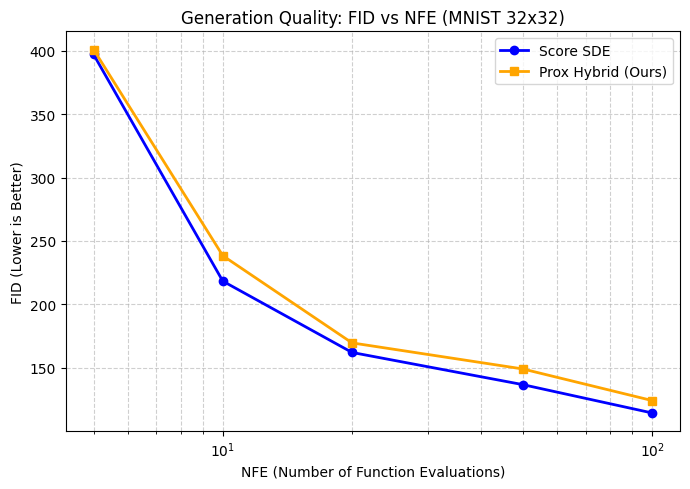

In [43]:
from tqdm.auto import tqdm
from torchmetrics.image.fid import FrechetInceptionDistance

def compute_fid(real_images, fake_images, batch_size=128):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    
    real_rgb = real_images.repeat(1, 3, 1, 1)
    fake_rgb = fake_images.repeat(1, 3, 1, 1)
    
    real_rgb = ((real_rgb + 1.0) / 2.0).clamp(0, 1)
    fake_rgb = ((fake_rgb + 1.0) / 2.0).clamp(0, 1)
    
    for i in range(0, len(real_rgb), batch_size):
        fid.update(real_rgb[i:i+batch_size], real=True)
    
    for i in range(0, len(fake_rgb), batch_size):
        fid.update(fake_rgb[i:i+batch_size], real=False)
        
    return fid.compute().item()

n_eval_samples = 1024
print(f"Collecting {n_eval_samples} real reference images...")

real_batches = []
while sum(b.shape[0] for b in real_batches) < n_eval_samples:
    real_batches.append(next_train_batch().to(device))
real_imgs = torch.cat(real_batches, dim=0)[:n_eval_samples]

nfe_candidates = [5, 10, 20, 50, 100]
data_dim = (cfg.in_ch, cfg.image_size, cfg.image_size)

fid_scores = []
fid_prox_hybrid = []

print("Generating images and calculating FID (this may take a few minutes)...")
for nfe in tqdm(nfe_candidates):
    fake_score = score_sample_euler_maruyama_eps(
        score_ema, sde, n_samples=n_eval_samples, n_steps=nfe, data_dim=data_dim
    )
    fid_scores.append(compute_fid(real_imgs, fake_score))
    
    fake_prox = prox_sample_hybrid(
        prox_ema, sde, n_samples=n_eval_samples, n_steps=nfe, data_dim=data_dim
    )
    fid_prox_hybrid.append(compute_fid(real_imgs, fake_prox))

plt.figure(figsize=(7, 5))

plt.plot(nfe_candidates, fid_scores, marker='o', label="Score SDE", color='blue', linewidth=2)
plt.plot(nfe_candidates, fid_prox_hybrid, marker='s', label="Prox Hybrid (Ours)", color='orange', linewidth=2)

plt.title("Generation Quality: FID vs NFE (MNIST 32x32)")
plt.xlabel("NFE (Number of Function Evaluations)")
plt.ylabel("FID (Lower is Better)")
plt.xscale('log')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Comments: FID is almost the same for both. In the paper (figure 2) prox is below score. In the paper the y axis is in log.

# Part 2 : Dino Data and batman data

For the second part i will try to train the model on the dino data. Instead of using a U net we use a classic MLP because target is not an image

Download dataset dino

Téléchargement des points du dinosaure...


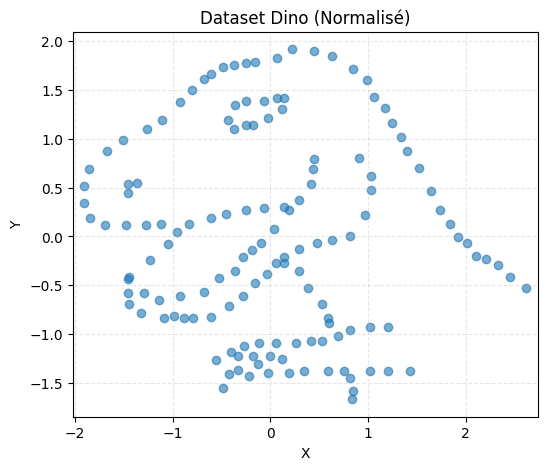

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class DinoDataset(Dataset):
    def __init__(self):
        url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-13/datasaurus.csv"
        print("Download dino points")
        df = pd.read_csv(url)
        
        dino_df = df[df['dataset'] == 'dino']
        
        x = dino_df['x'].values
        y = dino_df['y'].values
        
        points = torch.tensor(list(zip(x, y)), dtype=torch.float32)
        

        self.points = (points - points.mean(dim=0)) / points.std(dim=0)
        
    def __len__(self):
        return len(self.points)
    
    def __getitem__(self, idx):
        return self.points[idx]

dino_dataset = DinoDataset()

dino_dataloader = DataLoader(dino_dataset, batch_size=32, shuffle=True, drop_last=False)


batch = next(iter(dino_dataloader))

plt.figure(figsize=(6, 5))
plt.scatter(dino_dataset.points[:, 0], dino_dataset.points[:, 1], alpha=0.6, color='#1f77b4')
plt.title("Dataset Dino (normalize)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, linestyle="--", alpha=0.3)
plt.axis("equal") 
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-13/datasaurus.csv"
df = pd.read_csv(url)
dino_df = df[df['dataset'] == 'dino']
points = torch.tensor(list(zip(dino_df['x'].values, dino_df['y'].values)), dtype=torch.float32)
dino_points = (points - points.mean(dim=0)) / points.std(dim=0)

def get_batch(batch_size=2048):
    idx = torch.randint(0, len(dino_points), (batch_size,))
    return dino_points[idx].to(device)

# 2. MLP 
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

def sinusoidal_embedding(scalars, dim):
    scalars = scalars * 1000.0
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=scalars.device, dtype=torch.float32) / (half - 1))
    angles = scalars[:, None].float() * freqs[None, :]
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

class ScalarEmbedding(nn.Module):
    def __init__(self, d_model, out_dim):
        super().__init__()
        self.d_model = d_model
        self.mlp = nn.Sequential(nn.Linear(d_model, out_dim), Swish(), nn.Linear(out_dim, out_dim))

    def forward(self, s):
        return self.mlp(sinusoidal_embedding(s, self.d_model))

class TimeConditionedBlock(nn.Module):
    def __init__(self, dim, emb_dim):
        super().__init__()
        self.mlp = nn.Sequential(Swish(), nn.Linear(emb_dim, dim))
        self.norm = nn.LayerNorm(dim)
        self.net = nn.Sequential(
            nn.Linear(dim, dim), Swish(), nn.Linear(dim, dim)
        )

    def forward(self, x, emb):
        h = x + self.mlp(emb)
        return x + self.net(self.norm(h))

class RobustMLP(nn.Module):
    def __init__(self, in_ch=2, ch=128, num_blocks=4, with_lamb=False):
        super().__init__()
        self.with_lamb = with_lamb
        emb_dim = ch * 2
        
        self.time_emb = ScalarEmbedding(ch, emb_dim if not with_lamb else emb_dim // 2)
        if with_lamb:
            self.lamb_emb = ScalarEmbedding(ch, emb_dim // 2)
            
        self.in_proj = nn.Linear(in_ch, ch)
        self.blocks = nn.ModuleList([TimeConditionedBlock(ch, emb_dim) for _ in range(num_blocks)])
        self.out_proj = nn.Linear(ch, in_ch)
        
    def forward(self, x, t, lamb=None):
        if self.with_lamb:
            emb = torch.cat([self.time_emb(t), self.lamb_emb(lamb)], dim=1)
        else:
            emb = self.time_emb(t)
            
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h, emb)
        return self.out_proj(h)

# 3. SDE and Prox/Score
class SDE:
    def __init__(self, beta_min, beta_max):
        self.beta_min = beta_min
        self.beta_max = beta_max

    def beta(self, t):
        return self.beta_min + (self.beta_max - self.beta_min) * t

    def beta_integral(self, a, b):
        return (self.beta(a) + self.beta(b)) * (b - a) / 2

class ScoreModel(nn.Module):
    def __init__(self, eps_net, beta_min, beta_max):
        super().__init__()
        self.eps_net = eps_net
        self.sde = SDE(beta_min, beta_max)

    def compute_epsilon(self, x, t):
        return self.eps_net(x, t)

    def forward(self, x, t):
        alpha_t = torch.exp(-self.sde.beta_integral(0, t)).view(-1, 1)
        eps = self.eps_net(x, t)
        return -eps / torch.sqrt(1 - alpha_t)

class ProxModel(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.net = net

    def forward(self, x, t, lamb):
        return x - self.net(x, t, lamb) * torch.sqrt(lamb).view(-1, 1)

    def compute_epsilon(self, x, t, lamb):
        return self.net(x, t, lamb)

#  4. losses and train 
class ProximalMatchingLoss(nn.Module):
    def forward(self, pred, target, gamma):
        b = pred.shape[0]
        mse = (pred - target).pow(2).reshape(b, -1).mean(1)
        return 1.0 - torch.exp(-(mse / (gamma**2)))

def sample_t_score(batch_size, device):
    return torch.rand(batch_size, device=device)

def sample_t_lamb(batch_size, sde, device, candidates):
    n_steps_candidates = torch.tensor(candidates, device=device)
    weights = torch.log10(n_steps_candidates.float())
    idx = torch.multinomial(weights, batch_size, replacement=True)
    n_steps = n_steps_candidates[idx]
    
    delta_t = 1.0 / n_steps
    t = torch.rand(batch_size, device=device)
    t = torch.floor(t / delta_t) * delta_t
    t = torch.clamp(t, max=1 - delta_t)
    
    t_plus = t + delta_t
    eff = sde.beta_integral(t, t_plus)
    lamb = eff # Hybrid discretization
    
    return t, lamb

class ScoreTrainerVP(nn.Module):
    def __init__(self, model, beta_min, beta_max):
        super().__init__()
        self.model = model
        self.sde = SDE(beta_min, beta_max)

    def forward(self, x0):
        t = sample_t_score(x0.shape[0], x0.device)
        alpha_t = torch.exp(-self.sde.beta_integral(0, t)).view(-1, 1)
        noise = torch.randn_like(x0)
        x_t = torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * noise
        pred = self.model.compute_epsilon(x_t, t)
        return F.mse_loss(pred, noise, reduction="none").mean(dim=1)

class ProxTrainerVP(nn.Module):
    def __init__(self, model, beta_min, beta_max):
        super().__init__()
        self.model = model
        self.sde = SDE(beta_min, beta_max)
        self.pm_loss = ProximalMatchingLoss()

    def forward(self, x0, loss_params, candidates):
        t, lamb = sample_t_lamb(x0.shape[0], self.sde, x0.device, candidates)
        alpha_t = torch.exp(-self.sde.beta_integral(0, t)).view(-1, 1)
        eps_t = torch.randn_like(x0)
        x_t = torch.sqrt(alpha_t) * x0 + torch.sqrt(1 - alpha_t) * eps_t

        eps_pm = torch.randn_like(x0)
        y = x_t + torch.sqrt(lamb).view(-1, 1) * eps_pm

        pred = self.model.compute_epsilon(y, t, lamb)
        target = eps_pm

        if loss_params["type"] == "mse":
            return F.mse_loss(pred, target, reduction="none").mean(dim=1)
        elif loss_params["type"] == "l1":
            return F.l1_loss(pred, target, reduction="none").mean(dim=1)
        else:
            return self.pm_loss(pred, target, loss_params["gamma"])

# 5. sampling (inference)
@torch.no_grad()
def score_sample_euler_maruyama_eps(model, sde, n_samples, n_steps, time_eps=1e-3):
    x = torch.randn(n_samples, 2, device=device)
    times = torch.linspace(1.0, time_eps, n_steps, device=device)

    for i in range(n_steps):
        t_now = times[i]
        dt = time_eps if i == n_steps - 1 else (1.0 - time_eps) / (n_steps - 1)
        eff = sde.beta(t_now) * dt
        vec_t = torch.full((x.shape[0],), t_now, device=x.device)
        score = model(x, vec_t)
        noise = 0.0 if i == n_steps - 1 else torch.randn_like(x)
        x = (1 + 0.5 * eff) * x + eff * score + torch.sqrt(eff) * noise
    return x

@torch.no_grad()
def prox_sample_hybrid(model, sde, n_samples, n_steps, time_eps=0.0):
    x = torch.randn(n_samples, 2, device=device)
    times = torch.linspace(time_eps, 1.0, n_steps + 1, device=device)

    for i in range(n_steps - 1, -1, -1):
        t_now, t_new = times[i + 1], times[i]
        eff = sde.beta_integral(t_new, t_now)
        lamb = eff

        y = (1 + 0.5 * eff) * x + torch.sqrt(eff) * torch.randn_like(x)
        vec_t = torch.full((x.shape[0],), t_new, device=x.device)
        vec_l = torch.full((x.shape[0],), lamb, device=x.device)
        x = model(y, vec_t, vec_l)
    return x

# 6. config and schedule
def ema_update(model, ema_model, decay=0.999):
    with torch.no_grad():
        for ema_p, p in zip(ema_model.parameters(), model.parameters()):
            ema_p.mul_(decay).add_(p, alpha=1 - decay)

class PMLossSchedule:
    def __init__(self, total_iters):
        pass

    def get(self, it):
        return {"type": "mse"}, 1e-3


Defining vraibles and functions

In [ ]:
beta_min = 0.1
beta_max = 20.0
total_iters = 50_000

score_net = RobustMLP(in_ch=2, ch=512, num_blocks=4, with_lamb=False).to(device)
prox_net = RobustMLP(in_ch=2, ch=512, num_blocks=4, with_lamb=True).to(device)

score_model = ScoreModel(score_net, beta_min, beta_max).to(device)
prox_model = ProxModel(prox_net).to(device)

score_ema = copy.deepcopy(score_model).eval()
prox_ema = copy.deepcopy(prox_model).eval()

score_trainer = ScoreTrainerVP(score_model, beta_min, beta_max).to(device)
prox_trainer = ProxTrainerVP(prox_model, beta_min, beta_max).to(device)

score_opt = torch.optim.AdamW(score_model.parameters(), lr=1e-3)
prox_opt = torch.optim.AdamW(prox_model.parameters(), lr=1e-3)

pm_schedule = PMLossSchedule(total_iters)
candidates = (5, 10, 20, 50, 100)

score_model.train()
prox_model.train()


history_iters = []
history_score_loss = []
history_prox_loss = []

Training

In [ ]:
for it in range(1, total_iters + 1):
    x = get_batch(batch_size=2048)

    # train score
    score_opt.zero_grad()
    loss_s = score_trainer(x).mean()
    loss_s.backward()
    torch.nn.utils.clip_grad_norm_(score_model.parameters(), max_norm=1.0) #avoid exploding parameters
    score_opt.step()
    ema_update(score_model, score_ema)

    # training ProxDM
    loss_params, lr = pm_schedule.get(it)
    for g in prox_opt.param_groups:
        g['lr'] = lr
        
    prox_opt.zero_grad()
    loss_p = prox_trainer(x, loss_params, candidates).mean()
    loss_p.backward()
    torch.nn.utils.clip_grad_norm_(prox_model.parameters(), max_norm=1.0)
    prox_opt.step()
    ema_update(prox_model, prox_ema)

    history_iters.append(it)
    history_score_loss.append(loss_s.item())
    history_prox_loss.append(loss_p.item())
    
    if it % 3000 == 0:
        print(f"Iter {it}/{total_iters} | Score Loss: {loss_s.item():.4f} | Prox Loss: {loss_p.item():.4f}")

Iter 3000/50000 | Score Loss: 0.2555 | Prox Loss: 0.7011
Iter 6000/50000 | Score Loss: 0.2517 | Prox Loss: 0.7239
Iter 9000/50000 | Score Loss: 0.2546 | Prox Loss: 0.7325
Iter 12000/50000 | Score Loss: 0.2382 | Prox Loss: 0.7297
Iter 15000/50000 | Score Loss: 0.2480 | Prox Loss: 0.7426
Iter 18000/50000 | Score Loss: 0.2493 | Prox Loss: 0.7385
Iter 21000/50000 | Score Loss: 0.2220 | Prox Loss: 0.7469
Iter 24000/50000 | Score Loss: 0.2282 | Prox Loss: 0.7562
Iter 27000/50000 | Score Loss: 0.2413 | Prox Loss: 0.7173
Iter 30000/50000 | Score Loss: 0.2413 | Prox Loss: 0.7178
Iter 33000/50000 | Score Loss: 0.2480 | Prox Loss: 0.7365
Iter 36000/50000 | Score Loss: 0.2582 | Prox Loss: 0.7217
Iter 39000/50000 | Score Loss: 0.2651 | Prox Loss: 0.7358
Iter 42000/50000 | Score Loss: 0.2335 | Prox Loss: 0.7100
Iter 45000/50000 | Score Loss: 0.2325 | Prox Loss: 0.7255
Iter 48000/50000 | Score Loss: 0.2491 | Prox Loss: 0.7276


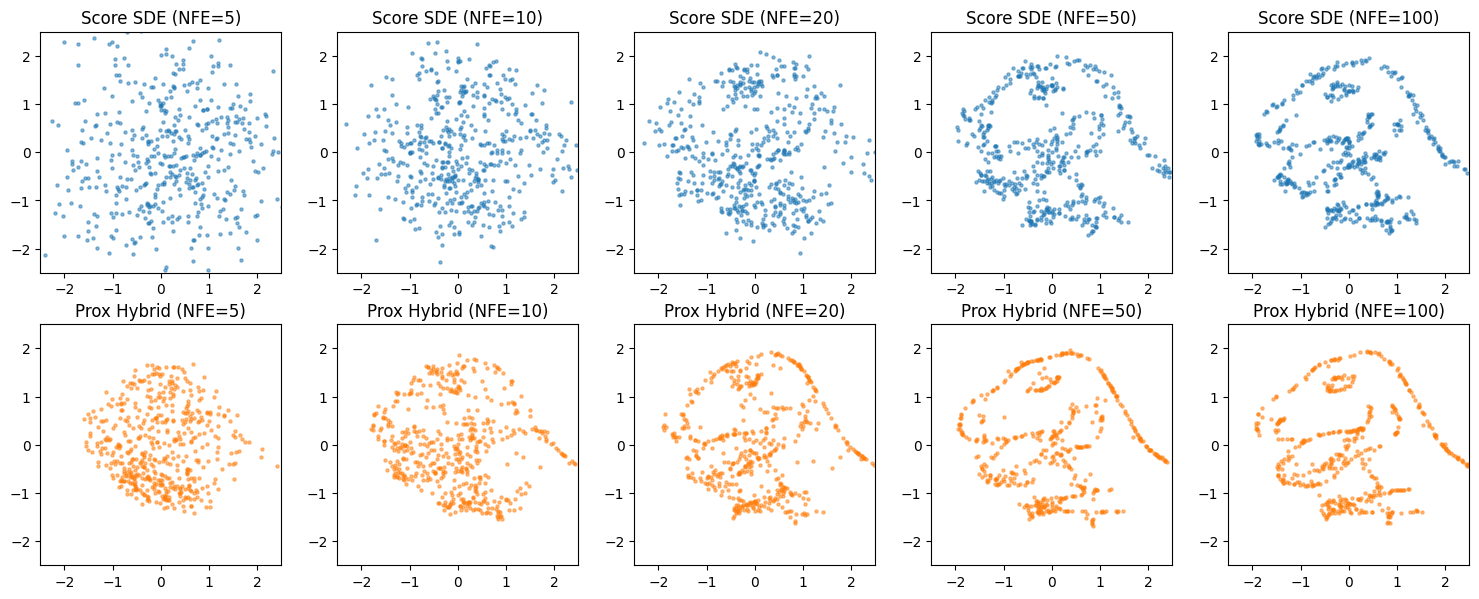

In [ ]:
def compare_methods(score_ema, prox_ema, sde, nfe_list=[5, 10, 20, 50, 100], n_samples=500):
    fig, axes = plt.subplots(2, len(nfe_list), figsize=(3 * len(nfe_list), 6))

    for i, nfe in enumerate(nfe_list):
        score_samples = score_sample_euler_maruyama_eps(score_ema, sde, n_samples, nfe).cpu().numpy()
        axes[0, i].scatter(score_samples[:, 0], score_samples[:, 1], alpha=0.5, s=5, color='#1f77b4')
        axes[0, i].set_title(f"Score SDE (NFE={nfe})")
        axes[0, i].set_xlim(-2.5, 2.5)
        axes[0, i].set_ylim(-2.5, 2.5)
        axes[0, i].set_aspect('equal', adjustable='box')

        prox_samples = prox_sample_hybrid(prox_ema, sde, n_samples, nfe).cpu().numpy()
        axes[1, i].scatter(prox_samples[:, 0], prox_samples[:, 1], alpha=0.5, s=5, color='#ff7f0e')
        axes[1, i].set_title(f"Prox Hybrid (NFE={nfe})")
        axes[1, i].set_xlim(-2.5, 2.5)
        axes[1, i].set_ylim(-2.5, 2.5)
        axes[1, i].set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()



In [ ]:
compare_methods(score_ema, prox_ema, SDE(beta_min, beta_max))

Comments: Prox hybrid is fart better than sde in this exemple

In [4]:
def plot_training_losses(iters, score_losses, prox_losses, window_size=50):
    """
    Trace les courbes de loss avec une moyenne mobile pour lisser le bruit.
    """
    def smooth(y, box_pts):
        box = np.ones(box_pts)/box_pts
        y_smooth = np.convolve(y, box, mode='valid')
        return y_smooth

    plt.figure(figsize=(10, 5))
    
    # Courbes lissées
    iters_smooth = iters[window_size-1:]
    plt.plot(iters_smooth, smooth(score_losses, window_size), label='Score SDE Loss (Lissée)', color='#1f77b4', linewidth=2)
    plt.plot(iters_smooth, smooth(prox_losses, window_size), label='ProxDM Loss (Lissée)', color='#ff7f0e', linewidth=2)
    
    plt.yscale('log') 
    plt.xlabel('Itérations')
    plt.ylabel('Loss')
    plt.title('Comparaison de la convergence : Score SDE vs ProxDM')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

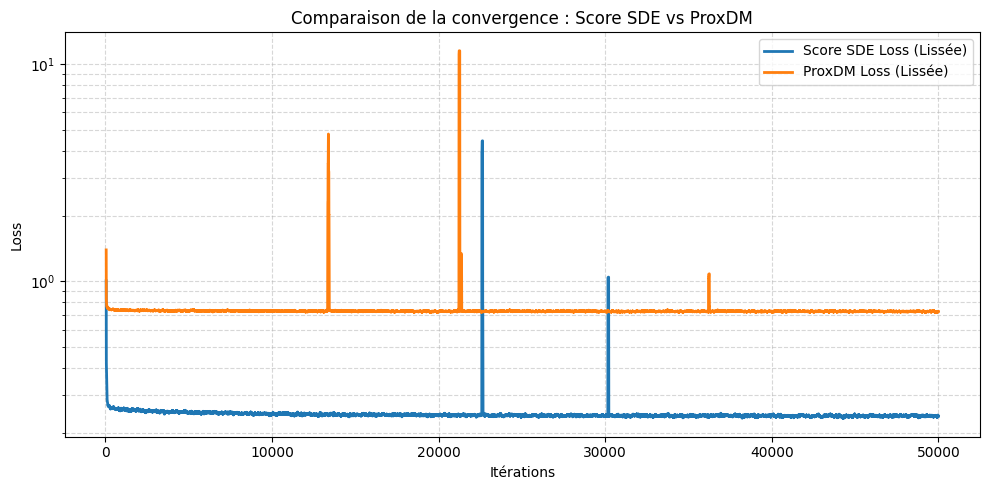

In [ ]:
plot_training_losses(history_iters, history_score_loss, history_prox_loss)

Comments: We see some vanishing gradients (spikes) such as said in the report

## Test with my own data

data from a batman's logo equation from internet

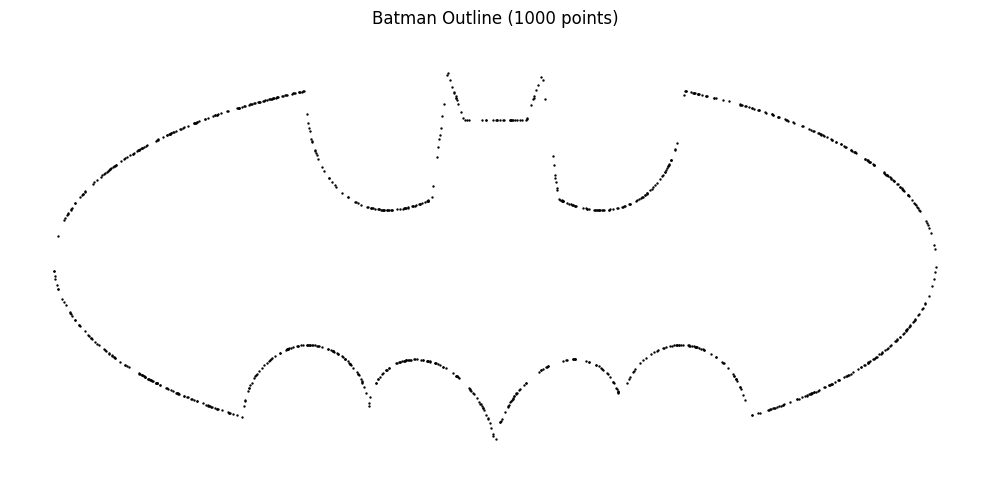

In [5]:
def get_batman_outline(num_points=1000):
    n = int(num_points * 0.6)
    x_u, x_l = np.random.uniform(-7, 7, n), np.random.uniform(-7, 7, n)
    ax_u, ax_l = np.abs(x_u), np.abs(x_l)
    U, L = np.zeros(n), np.zeros(n)

    U[ax_u < 0.5] = 2.25
    
    m1 = (ax_u >= 0.5) & (ax_u < 0.75)
    U[m1] = 3 * ax_u[m1] + 0.75
    
    m2 = (ax_u >= 0.75) & (ax_u < 1)
    U[m2] = 9 - 8 * ax_u[m2]
    
    m3 = (ax_u >= 1) & (ax_u < 3)
    U[m3] = 1.5 - 0.5 * ax_u[m3] - (3 * np.sqrt(10) / 7) * (np.sqrt(np.clip(3 - ax_u[m3]**2 + 2 * ax_u[m3], 0, None)) - 2)
    
    m4 = (ax_u >= 3) & (ax_u <= 7)
    U[m4] = 3 * np.sqrt(np.clip(1 - (ax_u[m4] / 7)**2, 0, None))

    m5 = ax_l < 4
    L[m5] = ax_l[m5] / 2 - ((3 * np.sqrt(33) - 7) / 112) * ax_l[m5]**2 - 3 + np.sqrt(np.clip(1 - (np.abs(ax_l[m5] - 2) - 1)**2, 0, None))
    
    m6 = (ax_l >= 4) & (ax_l <= 7)
    L[m6] = -3 * np.sqrt(np.clip(1 - (ax_l[m6] / 7)**2, 0, None))

    pts = np.vstack((np.column_stack((x_u, U)), np.column_stack((x_l, L))))
    pts = pts[~np.isnan(pts).any(axis=1)]

    if len(pts) > num_points:
        pts = pts[np.random.choice(len(pts), num_points, replace=False)]

    plt.figure(figsize=(10, 5))
    plt.scatter(pts[:, 0], pts[:, 1], s=0.5, c='black')
    plt.title(f"Batman Outline ({len(pts)} points)")
    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return pts

dataset = get_batman_outline()

In [6]:
def get_batman_outline(num_points=8000):
    n = int(num_points * 0.6)
    x_u, x_l = np.random.uniform(-7, 7, n), np.random.uniform(-7, 7, n)
    ax_u, ax_l = np.abs(x_u), np.abs(x_l)
    U, L = np.zeros(n), np.zeros(n)

    U[ax_u < 0.5] = 2.25
    
    m1 = (ax_u >= 0.5) & (ax_u < 0.75)
    U[m1] = 3 * ax_u[m1] + 0.75
    
    m2 = (ax_u >= 0.75) & (ax_u < 1)
    U[m2] = 9 - 8 * ax_u[m2]
    
    m3 = (ax_u >= 1) & (ax_u < 3)
    U[m3] = 1.5 - 0.5 * ax_u[m3] - (3 * np.sqrt(10) / 7) * (np.sqrt(np.clip(3 - ax_u[m3]**2 + 2 * ax_u[m3], 0, None)) - 2)
    
    m4 = (ax_u >= 3) & (ax_u <= 7)
    U[m4] = 3 * np.sqrt(np.clip(1 - (ax_u[m4] / 7)**2, 0, None))

    m5 = ax_l < 4
    L[m5] = ax_l[m5] / 2 - ((3 * np.sqrt(33) - 7) / 112) * ax_l[m5]**2 - 3 + np.sqrt(np.clip(1 - (np.abs(ax_l[m5] - 2) - 1)**2, 0, None))
    
    m6 = (ax_l >= 4) & (ax_l <= 7)
    L[m6] = -3 * np.sqrt(np.clip(1 - (ax_l[m6] / 7)**2, 0, None))

    pts = np.vstack((np.column_stack((x_u, U)), np.column_stack((x_l, L))))
    pts = pts[~np.isnan(pts).any(axis=1)]

    if len(pts) > num_points:
        pts = pts[np.random.choice(len(pts), num_points, replace=False)]
        
    return pts

batman_numpy = get_batman_outline(num_points=1000) 
points = torch.tensor(batman_numpy, dtype=torch.float32)


batman_points = (points - points.mean(dim=0)) / points.std(dim=0)

def get_batch(batch_size=2048):
    idx = torch.randint(0, len(batman_points), (batch_size,))
    return batman_points[idx].to(device)

In [7]:
beta_min = 0.1
beta_max = 20.0
total_iters = 30_000

score_net = RobustMLP(in_ch=2, ch=512, num_blocks=4, with_lamb=False).to(device)
prox_net = RobustMLP(in_ch=2, ch=512, num_blocks=4, with_lamb=True).to(device)

score_model = ScoreModel(score_net, beta_min, beta_max).to(device)
prox_model = ProxModel(prox_net).to(device)

score_ema = copy.deepcopy(score_model).eval()
prox_ema = copy.deepcopy(prox_model).eval()

score_trainer = ScoreTrainerVP(score_model, beta_min, beta_max).to(device)
prox_trainer = ProxTrainerVP(prox_model, beta_min, beta_max).to(device)

score_opt = torch.optim.AdamW(score_model.parameters(), lr=1e-3)
prox_opt = torch.optim.AdamW(prox_model.parameters(), lr=1e-3)

pm_schedule = PMLossSchedule(total_iters)
candidates = (5, 10, 20, 50, 100)

score_model.train()
prox_model.train()


history_iters = []
history_score_loss = []
history_prox_loss = []

In [ ]:
for it in range(1, total_iters + 1):
    x = get_batch(batch_size=512)

    # Training Score SDE
    score_opt.zero_grad()
    loss_s = score_trainer(x).mean()
    loss_s.backward()
    torch.nn.utils.clip_grad_norm_(score_model.parameters(), max_norm=1.0) 
    score_opt.step()
    ema_update(score_model, score_ema)

    # Training ProxDM
    loss_params, lr = pm_schedule.get(it)
    for g in prox_opt.param_groups:
        g['lr'] = lr
        
    prox_opt.zero_grad()
    loss_p = prox_trainer(x, loss_params, candidates).mean()
    loss_p.backward()
    torch.nn.utils.clip_grad_norm_(prox_model.parameters(), max_norm=1.0)
    prox_opt.step()
    ema_update(prox_model, prox_ema)

    history_iters.append(it)
    history_score_loss.append(loss_s.item())
    history_prox_loss.append(loss_p.item())
    
    if it % 3000 == 0:
        print(f"Iter {it}/{total_iters} | Score Loss: {loss_s.item():.4f} | Prox Loss: {loss_p.item():.4f}")

Iter 3000/30000 | Score Loss: 0.2552 | Prox Loss: 0.7187
Iter 6000/30000 | Score Loss: 0.2521 | Prox Loss: 0.7208
Iter 9000/30000 | Score Loss: 0.2317 | Prox Loss: 0.7511
Iter 12000/30000 | Score Loss: 0.2382 | Prox Loss: 0.7560
Iter 15000/30000 | Score Loss: 0.2518 | Prox Loss: 0.7058
Iter 18000/30000 | Score Loss: 0.2296 | Prox Loss: 0.7923
Iter 21000/30000 | Score Loss: 0.2214 | Prox Loss: 0.6273
Iter 24000/30000 | Score Loss: 0.2210 | Prox Loss: 0.7140
Iter 27000/30000 | Score Loss: 0.2494 | Prox Loss: 0.7416
Iter 30000/30000 | Score Loss: 0.2579 | Prox Loss: 0.7021


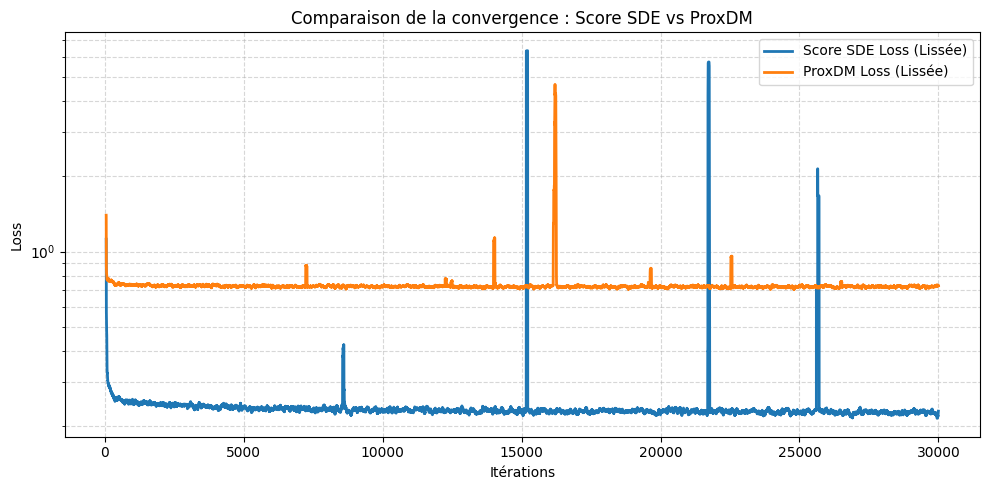

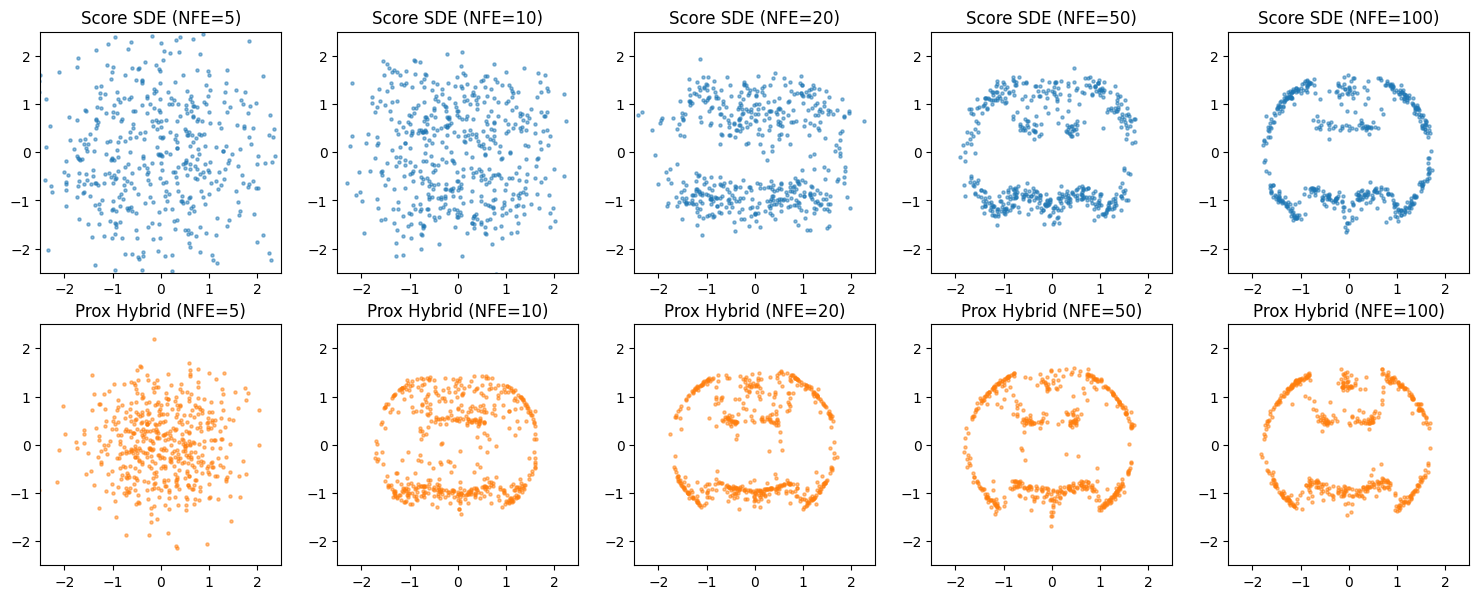

In [10]:
plot_training_losses(history_iters, history_score_loss, history_prox_loss)
compare_methods(score_ema, prox_ema, SDE(beta_min, beta_max))